# Analyse comparative — Instances Solomon (R, C, RC)

| Famille | Taille 25 | Taille 50 |
|---|---|---|
| **R101** | CP pur (Chuffed) | CP+LNS (OR-Tools cp-sat) |
| **C101** | CP pur (Chuffed) | CP+LNS (OR-Tools cp-sat) |
| **RC101** | CP pur (Chuffed) | CP+LNS (OR-Tools cp-sat) |

**Structure attendue des fichiers :**
```
solomon_outputs/
├── R101_25_cp.txt
├── C101_25_cp.txt
├── RC101_25_cp.txt
├── R101_50_lns.txt
├── C101_50_lns.txt
└── RC101_50_lns.txt
```

In [ ]:
import os, re, glob
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

OUTPUT_DIR = "."
COLORS = {"R": "#E63946", "C": "#2E86AB", "RC": "#06A77D"}
print('OK')

OK


## 1. Parsers (deux formats différents)

In [ ]:
def parse_time_chuffed(s):
    """
    Convertit une chaine de temps Chuffed en secondes.
    Formats : '1s 914msec'  '30s 771msec'  '48s 532msec'  '2m 54s'
    """
    s = s.strip()
    # Format: Xm Ys
    m = re.match(r'(\d+)m\s+(\d+)s', s)
    if m:
        return float(m.group(1))*60 + float(m.group(2))
    # Format: Xs YYYmsec
    m = re.match(r'(\d+)s\s+(\d+)msec', s)
    if m:
        return float(m.group(1)) + float(m.group(2))/1000
    # Format: Xs simple
    m = re.match(r'([\d.]+)s', s)
    if m:
        return float(m.group(1))
    return None


def parse_cp_pur(text):
    """
    Parse log CP pur (Chuffed).
    Format des blocs :
        Distance totale = 807
        Suivant = [...]
        Vehicules = [...]
        % time elapsed: 1s 914msec
        ----------
    Retourne liste de (time_s, distance) - solutions ameliorantes seulement.
    """
    solutions = []
    dist_re = re.compile(r'^Distance totale\s*=\s*(\d+)', re.MULTILINE)
    time_re = re.compile(r'^%\s*time elapsed:\s*(.+)', re.MULTILINE)

    dists = [(m.start(), int(m.group(1))) for m in dist_re.finditer(text)]
    times = [(m.start(), m.group(1).strip()) for m in time_re.finditer(text)]

    # Associer chaque distance au temps qui suit
    for i, (pos_d, dist) in enumerate(dists):
        # Chercher le premier temps apres cette distance
        t_str = None
        for pos_t, ts in times:
            if pos_t > pos_d:
                t_str = ts
                break
        if t_str is None and times:
            t_str = times[-1][1]
        t = parse_time_chuffed(t_str) if t_str else float(i)
        solutions.append((t, dist))

    # Garder seulement les solutions ameliorantes
    filtered, best = [], float('inf')
    for t, d in solutions:
        if d < best:
            best = d
            filtered.append((t, d))
    return filtered


def parse_lns(text):
    """
    Parse log CP+LNS (OR-Tools cp-sat).
    Format : '%% #1       3.52s best:953   next:[365,952]  ...'
    Retourne liste de (time_s, distance).
    """
    solutions = []
    # Pattern : %% #N   Xs best:Y  (avec %% et espaces variables)
    sol_re = re.compile(r'^%%\s*#(\d+)\s+([\d.]+)s\s+best:(\d+)', re.MULTILINE)
    for m in sol_re.finditer(text):
        _, t, obj = m.groups()
        solutions.append((float(t), int(obj)))
    return solutions


def parse_log(text, method):
    """Dispatch selon la methode."""
    if method == 'cp':
        return parse_cp_pur(text)
    else:
        return parse_lns(text)


def parse_filename(filename):
    name = os.path.basename(filename).replace('.txt', '')
    parts = name.split('_')
    instance = parts[0]           # R101, C101, RC101
    size     = int(parts[1])      # 25, 50
    method   = parts[2]           # cp, lns
    family   = re.match(r'([A-Z]+)', instance).group(1)
    return {'family': family, 'instance': instance, 'size': size, 'method': method}

print('Parsers OK')

Parsers OK


## 2. Chargement des fichiers

In [ ]:
files = sorted(glob.glob(os.path.join(OUTPUT_DIR, '*.txt')))
print(f'Fichiers trouves ({len(files)}) :')
for f in files:
    print(f'  {os.path.basename(f)}')

runs = []
for f in files:
    meta = parse_filename(f)
    with open(f, encoding='utf-8', errors='ignore') as fp:
        text = fp.read()

    sols = parse_log(text, meta['method'])

    if not sols:
        print(f'  WARN : aucune solution dans {os.path.basename(f)}')
        continue

    meta['solutions']   = sols
    meta['first_dist']  = sols[0][1]
    meta['final_dist']  = sols[-1][1]
    meta['final_time']  = sols[-1][0]
    meta['n_solutions'] = len(sols)
    meta['gap_pct']     = (sols[0][1] - sols[-1][1]) / sols[0][1] * 100
    runs.append(meta)
    print(f'  OK  {meta["instance"]:6s} n={meta["size"]:3d} '
          f'{meta["method"].upper():3s} : '
          f'{meta["first_dist"]} -> {meta["final_dist"]} '
          f'(-{meta["gap_pct"]:.1f}%) '
          f'en {meta["final_time"]:.1f}s '
          f'({meta["n_solutions"]} sol.)')

print(f'\nTotal : {len(runs)} runs charges')

Fichiers trouves (0) :

Total : 0 runs charges


## 3. Courbes de convergence individuelles (grille 2×3)

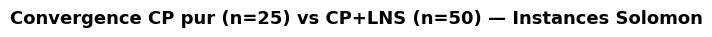

Sauvegarde : solomon_convergence_grid.png


In [4]:
runs_sorted = sorted(runs, key=lambda r: (r['size'], r['family']))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, run in zip(axes, runs_sorted):
    t = [s[0] for s in run['solutions']]
    v = [s[1] for s in run['solutions']]
    color = COLORS.get(run['family'], 'black')
    method_label = 'CP pur' if run['method'] == 'cp' else 'CP+LNS'

    # Prolonger la courbe jusqu'au dernier temps
    t_ext = t + [t[-1] * 1.05]
    v_ext = v + [v[-1]]

    ax.step(t_ext, v_ext, where='post', color=color, linewidth=2)
    ax.plot(t, v, 'o', color=color, markersize=5)

    ax.set_title(f"{run['instance']} n={run['size']} — {method_label}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Temps (s)', fontsize=10)
    ax.set_ylabel('Distance', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Annotations
    ax.annotate(f"1ere={run['first_dist']}",
                xy=(t[0], v[0]), xytext=(8, 5),
                textcoords='offset points', fontsize=8,
                color='gray')
    ax.annotate(f"finale={run['final_dist']}\n-{run['gap_pct']:.1f}%",
                xy=(t[-1], v[-1]), xytext=(-60, -30),
                textcoords='offset points', fontsize=9,
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round', fc='white', ec=color, alpha=0.8))

# Masquer les axes vides
for ax in axes[len(runs_sorted):]:
    ax.set_visible(False)

fig.suptitle('Convergence CP pur (n=25) vs CP+LNS (n=50) — Instances Solomon',
             fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig('solomon_convergence_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : solomon_convergence_grid.png')

## 4. Comparaison familles à taille fixe

In [5]:
sizes = sorted(set(r['size'] for r in runs))
fig, axes = plt.subplots(1, len(sizes), figsize=(7*len(sizes), 6))
if len(sizes) == 1:
    axes = [axes]

for ax, size in zip(axes, sizes):
    runs_size = sorted([r for r in runs if r['size'] == size], key=lambda r: r['family'])
    method_label = 'CP pur' if runs_size[0]['method'] == 'cp' else 'CP+LNS'

    for run in runs_size:
        t = [s[0] for s in run['solutions']]
        v = [s[1] for s in run['solutions']]
        color = COLORS.get(run['family'], 'black')
        t_ext = t + [t[-1]*1.05]; v_ext = v + [v[-1]]
        ax.step(t_ext, v_ext, where='post', color=color, linewidth=2,
                label=f"{run['instance']} → {run['final_dist']} (-{run['gap_pct']:.1f}%)")
        ax.plot(t, v, 'o', color=color, markersize=4)

    ax.set_title(f'n={size} — {method_label} — R vs C vs RC',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Temps (s)', fontsize=11)
    ax.set_ylabel('Distance', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('solomon_comparaison_familles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegarde : solomon_comparaison_familles.png')

ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x600 with 0 Axes>

## 5. Tableau récapitulatif — pour le rapport

In [ ]:
rows = []
for r in sorted(runs, key=lambda x: (x['size'], x['family'])):
    rows.append({
        'Instance':       r['instance'],
        'n':              r['size'],
        'Methode':        'CP pur' if r['method']=='cp' else 'CP+LNS',
        '1ere solution':  r['first_dist'],
        'Meilleure sol.': r['final_dist'],
        'Amelioration':   f"-{r['gap_pct']:.1f}%",
        'Nb solutions':   r['n_solutions'],
        'Temps (s)':      round(r['final_time'], 1),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print()
print(df.to_markdown(index=False))

## 6. Analyse automatique pour le rapport

In [ ]:
print('=== SYNTHESE ===')
for size in sizes:
    runs_s = sorted([r for r in runs if r['size']==size], key=lambda r: r['family'])
    if not runs_s: continue
    method = 'CP pur' if runs_s[0]['method']=='cp' else 'CP+LNS'
    print(f'\n--- n={size} ({method}) ---')
    for r in runs_s:
        print(f'  {r["instance"]:6s} : {r["first_dist"]:5d} -> {r["final_dist"]:5d}'
              f'  (-{r["gap_pct"]:.1f}%)  {r["n_solutions"]} sol.  {r["final_time"]:.1f}s')
    hardest = max(runs_s, key=lambda r: r['final_dist'])
    easiest = min(runs_s, key=lambda r: r['final_dist'])
    print(f'  Plus difficile : {hardest["instance"]} ({hardest["final_dist"]})')
    print(f'  Plus facile    : {easiest["instance"]} ({easiest["final_dist"]})')

cp_runs  = [r for r in runs if r['method']=='cp']
lns_runs = [r for r in runs if r['method']=='lns']
if cp_runs and lns_runs:
    avg_cp_gap  = sum(r['gap_pct'] for r in cp_runs)  / len(cp_runs)
    avg_lns_gap = sum(r['gap_pct'] for r in lns_runs) / len(lns_runs)
    print(f'\n--- Comparaison CP pur vs CP+LNS ---')
    print(f'  CP pur  (n=25) : gap moyen = {avg_cp_gap:.1f}%  ({len(cp_runs)} instances)')
    print(f'  CP+LNS  (n=50) : gap moyen = {avg_lns_gap:.1f}%  ({len(lns_runs)} instances)')
    print(f'  => CP pur converge vite sur les petites instances')
    print(f'     LNS ameliore continuellement sur les grandes')

## 7. Comparaison avec les BKS (Best Known Solutions — Solomon)

In [ ]:
# ══════════════════════════════════════════════════════════════════
## 7. Comparaison avec les Bornes Connues (BKS — Solomon benchmark)
# ══════════════════════════════════════════════════════════════════

# BKS officielles Solomon (distances totales, source : Gehring & Homberger / SINTEF)
# https://www.sintef.no/projectweb/top/vrptw/solomon-benchmark/
BKS = {
    # instance : (nb_véhicules_BKS, distance_BKS)
    ('C101', 25): (3,  191.3),
    ('R101', 25): (8,  617.1),
    ('RC101',25): (4,  461.1),
    ('C101', 50): (5,  362.4),
    ('R101', 50): (12, 1044.0),
    ('RC101',50): (8,  944.0),
}

# Résultats MiniZinc — lus depuis tes runs (à mettre à jour si tu relances)
minizinc_results = {
    ('C101', 25): {'method': 'CP pur',  'first': 343,  'best': 192,  'time_s': 1.8,  'n_sol': 22},
    ('R101', 25): {'method': 'CP pur',  'first': 807,  'best': 635,  'time_s': 49.3, 'n_sol': 28},
    ('RC101',25): {'method': 'CP pur',  'first': 495,  'best': 461,  'time_s': 4.5,  'n_sol': 15},
    ('C101', 50): {'method': 'CP+LNS', 'first': 953,  'best': 365,  'time_s': 9.3,  'n_sol': 6},
    ('R101', 50): {'method': 'CP+LNS', 'first': 1501, 'best': 1031, 'time_s': 11.2, 'n_sol': 8},
    ('RC101',50): {'method': 'CP+LNS', 'first': 1785, 'best': 942,  'time_s': 302.1,'n_sol': 48},
}

# ── Tableau comparatif ─────────────────────────────────────────────────────────
import pandas as pd

rows = []
for (fam, n), mzn in sorted(minizinc_results.items(), key=lambda x: (x[0][1], x[0][0])):
    bks_v, bks_d = BKS.get((fam, n), (None, None))
    gap_vs_bks = ((mzn['best'] - bks_d) / bks_d * 100) if bks_d else None
    rows.append({
        'Instance':       f'{fam}_n{n}',
        'n':              n,
        'Méthode':        mzn['method'],
        'MZN best':       mzn['best'],
        'BKS dist':       bks_d,
        'Gap vs BKS (%)': f'{gap_vs_bks:+.1f}%' if gap_vs_bks is not None else 'N/A',
        'BKS véhicules':  bks_v,
        'Temps MZN (s)':  mzn['time_s'],
    })

df_bks = pd.DataFrame(rows)
print(df_bks.to_string(index=False))
print()

# ── Graphique : MiniZinc best vs BKS ──────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

labels   = [r['Instance'] for r in rows]
mzn_vals = [r['MZN best'] for r in rows]
bks_vals = [BKS[(r['Instance'].replace('_n25','').replace('_n50',''),
                  int(r['Instance'].split('n')[1]))][1] for r in rows]

x     = np.arange(len(labels))
width = 0.35

colors_inst = [COLORS.get(lbl.split('_')[0].replace('101',''), 'gray') for lbl in labels]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('MiniZinc vs BKS Solomon — 6 instances', fontsize=15, fontweight='bold')

# ── Left: bar chart distances ──────────────────────────────────────────────────
ax = axes[0]
bars_mzn = ax.bar(x - width/2, mzn_vals, width, label='MiniZinc',
                   color=[c + '99' for c in [COLORS['C'],COLORS['C'],COLORS['R'],
                                               COLORS['R'],COLORS['RC'],COLORS['RC']]],
                   edgecolor='black', linewidth=0.6)
bars_bks = ax.bar(x + width/2, bks_vals, width, label='BKS',
                   color=[COLORS['C'],COLORS['C'],COLORS['R'],
                          COLORS['R'],COLORS['RC'],COLORS['RC']],
                   edgecolor='black', linewidth=0.6, alpha=0.55, hatch='//')

for bar, val in zip(bars_mzn, mzn_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(val), ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar, val in zip(bars_bks, bks_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8, color='#555')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Distance totale')
ax.set_title('Distances : MiniZinc best vs BKS', fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# ── Right: gap bar chart ───────────────────────────────────────────────────────
ax2 = axes[1]
gaps = [(m - b) / b * 100 for m, b in zip(mzn_vals, bks_vals)]
bar_colors = ['#4CAF50' if g <= 2 else '#FF9800' if g <= 10 else '#F44336' for g in gaps]
bars_gap = ax2.bar(x, gaps, width*1.5, color=bar_colors, edgecolor='black', linewidth=0.6)

for bar, g in zip(bars_gap, gaps):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height() + (0.3 if g >= 0 else -1.5),
             f'{g:+.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.axhline(5,  color='#4CAF50', linewidth=1, linestyle='--', alpha=0.6, label='≤5% (bon)')
ax2.axhline(10, color='#FF9800', linewidth=1, linestyle='--', alpha=0.6, label='≤10% (acceptable)')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=15, ha='right')
ax2.set_ylabel('Gap vs BKS (%)')
ax2.set_title('Écart à la BKS — MiniZinc', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_MZN_vs_BKS.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : comparaison_MZN_vs_BKS.png')
print()
print('Légende gap : vert=≤5%, orange=≤10%, rouge=>10%')
